# 텐서플로우 모델 구축 방법 3가지

# 딥러닝 라이브러리 2가지
## 텐서플로우(google) - 산업용
* 이미지 관련 라이브러리
* keras를 이용해 코딩이 쉬움
    * keras: tensorflow위에서 동작하는 딥러닝 모델을 쉽게 만들기 위한 python 라이브러리
* 순차적, 함수적, 클래스

## 파이토치(meta) - 연구용
* 자연어 관련 라이브러리
* 허깅페이스, 랭체인
* 클래스
* 학습의 모든 과정을 커스텀화 할 수 있음

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

In [2]:
data = pd.read_csv("https://raw.githubusercontent.com/haram4th/ablearn/main/Taitanic_train.csv")
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [4]:
data = data[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Embarked']]
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,0,3,male,22.0,1,0,S
1,1,1,female,38.0,1,0,C
2,1,3,female,26.0,0,0,S
3,1,1,female,35.0,1,0,S
4,0,3,male,35.0,0,0,S


In [5]:
data['family']=data['SibSp'] + data['Parch']
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked,family
0,0,3,male,22.0,1,0,S,1
1,1,1,female,38.0,1,0,C,1
2,1,3,female,26.0,0,0,S,0
3,1,1,female,35.0,1,0,S,1
4,0,3,male,35.0,0,0,S,0


In [6]:
data = data.drop(['SibSp', 'Parch'], axis=1)
data.head()

,Survived,Pclass,Sex,Age,Embarked,family
0,0,3,male,22.0,S,1
1,1,1,female,38.0,C,1
2,1,3,female,26.0,S,0
3,1,1,female,35.0,S,1
4,0,3,male,35.0,S,0


In [7]:
X = data.drop('Survived', axis=1)
y = data['Survived']

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, stratify=y, random_state=42)

In [10]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 623 entries, 748 to 136
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    623 non-null    int64  
 1   Sex       623 non-null    str    
 2   Age       504 non-null    float64
 3   Embarked  621 non-null    str    
 4   family    623 non-null    int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 29.2 KB


# 딥러닝시에도 데이터 스케일을 맞춰 주어야 함
* MinMaxScaler를 주로 사용, StandardScaler도 사용, 이상값이 많은 경우 RobustScaler 사용
* 이진분류: MinMaxScaler
* 연속값예측: StandardScaler

In [11]:
X_train.columns

Index(['Pclass', 'Sex', 'Age', 'Embarked', 'family'], dtype='str')

In [12]:
num_cols = ['Age', 'family']
cat_cols = ['Pclass', 'Sex', 'Embarked']

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer # 결측치 채워주는 도구
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer # 컬럼별로 다른 전처리를 적용하는 도구

In [14]:
num_pipe = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='mean')),
    ('mmx', MinMaxScaler())
])

cat_pipe = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])
# drop='first': 첫번째 카테고리 제거 (다중공선성 문제 방지)
# handle_unknown='ignore': 학습할 때 없던 새로운 카테고리가 나오면 에러 내지 않고 무시
# sprase_output=False: 출력을 희소행렬이 아니라 일반 배열로 반환
prep = ColumnTransformer(transformers=[
    ('num_cols', num_pipe, num_cols),
    ('cat_cols', cat_pipe, cat_cols)
], remainder='drop')

X_train_ppd = prep.fit_transform(X_train)
X_test_ppd = prep.transform(X_test)

# Tensorflow Sequential API를 사용한 순차적 모델 생성 및 분석
* Sequential: 인공신경망을 순차적으로 작성할 때 사용
* Dense: 층, 레이어, 입력층, 은닉층, 출력층
    * 입력층: 모델에 데이터를 넣는 층
    * 은닉층: 입력 데이터를 계산하고 패턴을 학습하는 층
    * 출력층: 모델이 최종 결과를 내는 층

In [15]:
import keras 
import tensorflow as tf
from keras import Input
from keras.models import Sequential
from keras.layers import Dense

2026-03-21 21:57:18.384324: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-21 21:57:18.756513: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-21 21:57:20.759755: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


* 뉴런: 입력값을 받아 계산해서 하나의 출력값을 만드는 작은 계산 단위 (입력 -> 계산 -> 출력)
* 입력층은 반드시 독립변수의수(input_dim)를 정확히 지정
* 신경망 모델의 은닉층은 2~3개 정도로 한다.
* Dense의 노드수는 2의 배수의 지정 2 4 8 16 256
* Dense의 노드는 큰 수에서 작은 수로 줄여나간다.
* 은닉층의 활성화 함수: Relu
    * 활성화 함수: 뉴런의 출력값을 변환하는 함수 (신경망이 복잡한 패턴을 학습하게 만들기 위해)
* 출력층은 이진분류일 경우 sigmoid, 다중분류일 경우 softmax
* 회귀분석일 경우(종속변수가 연속형(수치형)인 경우) 출력층에 활성화 함수 없이 노드를 1로 지정

In [37]:
X_train_ppd.shape[1] # 독립변수 수 계산 (열의 개수)

7

In [17]:
# # 옛날 버전 코드
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense

# model = Sequential()

# model.add(Dense(64,
#                 activation='relu',
#                 input_dim=X_train_ppd.shape[1]))  # 입력층

# model.add(Dense(32, activation='relu'))  # 은닉층
# model.add(Dense(16, activation='relu'))  # 은닉층

# model.add(Dense(1, activation='sigmoid'))  # 출력층

In [18]:
# keras 3.0 기준 신경망 모델 정의
model = Sequential()
model.add(Input(shape=(X_train_ppd.shape[1],))) # 입력층
model.add(Dense(64, activation = 'relu')) # 은닉층
model.add(Dense(32, activation = 'relu')) # 은닉층
model.add(Dense(16, activation = 'relu')) # 은닉층
model.add(Dense(1, activation='sigmoid')) # 출력층, 이진분류이므로 sigmoid

I0000 00:00:1774097841.964791  109215 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1347 MB memory:  -> device: 0, name: NVIDIA GeForce MX450, pci bus id: 0000:01:00.0, compute capability: 7.5


In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

* params: 각 레이어가 가지고 있는 학습 가능한 파라미터 개수
    * params = 가중치 + bias
    
* 첫번째 레이어 (None, 64)
    * 뉴런 64개 
    * Param # 512개 
        * (입력노드 * 출력노드) + 출력노드
        * (7 * 64) + 64
* 두번째 레이어 (None, 32)
    * 이 레이어의 입력은 이전 레이어의 64개 출력
        * (64 * 32) + 32

#  모델의 파라미터 세팅 model.compile()
* loss: 오차 계산 지표 (모델이 얼마나 틀렸는지 계산)
  * 이진분류: binary_crossentropy
  * 다중분류: categorical_crossentropy - y가 one-hot encoding
  * 다중분류2: sparse_categorical_crossentropy - y가 label encoding
  * 연속형데이터(회귀분석): mse
* optimizer: learning_rate ( 그 틀린 정도를 보고 어떻게 고칠지 결정)
  * adam을 가장 많이 사용
* metrics: 평가지표 accuracy

In [20]:
pd.get_dummies(y_train)

,0,1
748,True,False
45,True,False
28,False,True
633,True,False
403,True,False
...,...,...
476,True,False
190,False,True
736,True,False
462,True,False


In [21]:
# 모델의 파라미터 세팅
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# 모델 훈련 model.fit(X_train, y_train)
* epochs: 전체 데이터를 한 번 훈련하는 주기, 10-100 사이
    * 전체 데이터 학습 횟수
* batch_size: 전체 데이터를 쪼개서 훈련, 데이터의 묶음, 메모리에 맞춰서 크기 조절(2의 배수) 32, 64로 쪼개서 넣는 것 추천
    * 한번에 모델에 넣는 데이터 개수
* validation_data: 검증 데이터로 모델 검증 실시

In [22]:
history = model.fit(X_train_ppd, y_train, epochs=300, batch_size=16,
                   validation_data=(X_test_ppd, y_test))

Epoch 1/300


2026-03-21 21:57:23.680141: I external/local_xla/xla/service/service.cc:163] XLA service 0x73c8e800bb60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-21 21:57:23.680175: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce MX450, Compute Capability 7.5
2026-03-21 21:57:23.713702: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-21 21:57:23.886711: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92000


24/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6606 - loss: 0.6479 

I0000 00:00:1774097844.828207  110331 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.6292 - loss: 0.6134 - val_accuracy: 0.7201 - val_loss: 0.5628
Epoch 2/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7801 - loss: 0.5347 - val_accuracy: 0.8172 - val_loss: 0.5141
Epoch 3/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8010 - loss: 0.4907 - val_accuracy: 0.8172 - val_loss: 0.4726
Epoch 4/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8138 - loss: 0.4655 - val_accuracy: 0.8022 - val_loss: 0.4551
Epoch 5/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8026 - loss: 0.4524 - val_accuracy: 0.8172 - val_loss: 0.4426
Epoch 6/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8026 - loss: 0.4460 - val_accuracy: 0.8172 - val_loss: 0.4359
Epoch 7/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8106 - loss: 0.4378 - val_accuracy: 0.8172 - val_loss: 0.4323
Epoch 8/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8090 - loss: 0.4387 - val_accuracy: 0.8022 - val_loss: 0.

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8363 - loss: 0.3928 - val_accuracy: 0.7910 - val_loss: 0.4187
Epoch 52/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8363 - loss: 0.3905 - val_accuracy: 0.8172 - val_loss: 0.4178
Epoch 53/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8331 - loss: 0.3918 - val_accuracy: 0.7873 - val_loss: 0.4253
Epoch 54/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8347 - loss: 0.3915 - val_accuracy: 0.8172 - val_loss: 0.4184
Epoch 55/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8379 - loss: 0.3888 - val_accuracy: 0.7948 - val_loss: 0.4307
Epoch 56/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8363 - loss: 0.3913 - val_accuracy: 0.8022 - val_loss: 0.4230
Epoch 57/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8315 - loss: 0.3888 - val_accuracy: 0.8097 - val_loss: 0.4194
Epoch 58/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8347 - loss: 0.3902 - val_accuracy: 0.7873 - val_l

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8459 - loss: 0.3759 - val_accuracy: 0.8097 - val_loss: 0.4492
Epoch 102/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8395 - loss: 0.3737 - val_accuracy: 0.8097 - val_loss: 0.4569
Epoch 103/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8507 - loss: 0.3722 - val_accuracy: 0.8134 - val_loss: 0.4490
Epoch 104/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8331 - loss: 0.3788 - val_accuracy: 0.7761 - val_loss: 0.4636
Epoch 105/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8427 - loss: 0.3740 - val_accuracy: 0.8172 - val_loss: 0.4498
Epoch 106/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8395 - loss: 0.3733 - val_accuracy: 0.8172 - val_loss: 0.4515
Epoch 107/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8411 - loss: 0.3719 - val_accuracy: 0.8060 - val_loss: 0.4573
Epoch 108/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8475 - loss: 0.3695 - val_accuracy: 0.7761 -

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8475 - loss: 0.3575 - val_accuracy: 0.7985 - val_loss: 0.4901
Epoch 152/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8459 - loss: 0.3601 - val_accuracy: 0.7985 - val_loss: 0.4895
Epoch 153/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8539 - loss: 0.3637 - val_accuracy: 0.7836 - val_loss: 0.4979
Epoch 154/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8427 - loss: 0.3626 - val_accuracy: 0.7910 - val_loss: 0.5016
Epoch 155/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8475 - loss: 0.3584 - val_accuracy: 0.7948 - val_loss: 0.4935
Epoch 156/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8555 - loss: 0.3561 - val_accuracy: 0.7836 - val_loss: 0.5026
Epoch 157/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8539 - loss: 0.3613 - val_accuracy: 0.7687 - val_loss: 0.5216
Epoch 158/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8571 - loss: 0.3569 - val_accuracy: 0.7948 -

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8620 - loss: 0.3433 - val_accuracy: 0.8022 - val_loss: 0.5541
Epoch 202/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8507 - loss: 0.3457 - val_accuracy: 0.7761 - val_loss: 0.5749
Epoch 203/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8539 - loss: 0.3462 - val_accuracy: 0.7910 - val_loss: 0.5318
Epoch 204/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8571 - loss: 0.3459 - val_accuracy: 0.7873 - val_loss: 0.5563
Epoch 205/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8620 - loss: 0.3456 - val_accuracy: 0.7985 - val_loss: 0.5531
Epoch 206/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8604 - loss: 0.3439 - val_accuracy: 0.7948 - val_loss: 0.5480
Epoch 207/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8539 - loss: 0.3434 - val_accuracy: 0.7724 - val_loss: 0.5968
Epoch 208/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8587 - loss: 0.3472 - val_accuracy: 0.7985 -

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8555 - loss: 0.3345 - val_accuracy: 0.7948 - val_loss: 0.6301
Epoch 252/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8652 - loss: 0.3342 - val_accuracy: 0.7910 - val_loss: 0.6356
Epoch 253/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8636 - loss: 0.3347 - val_accuracy: 0.7799 - val_loss: 0.6459
Epoch 254/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8475 - loss: 0.3373 - val_accuracy: 0.7985 - val_loss: 0.6265
Epoch 255/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8636 - loss: 0.3313 - val_accuracy: 0.7761 - val_loss: 0.6604
Epoch 256/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8604 - loss: 0.3332 - val_accuracy: 0.7910 - val_loss: 0.6242
Epoch 257/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8620 - loss: 0.3321 - val_accuracy: 0.7985 - val_loss: 0.6234
Epoch 258/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8636 - loss: 0.3291 - val_accuracy: 0.7687 -

# 딥러닝 모델 성능 평가
* 딥러닝에서 모델의 성능을 평가하는 지표는 loss
* 보통 loss가 낮으면 accuracy가 올라가지만 비례하지 않을 때도 있음.
* accuracy와 loss 간의 차이가 있을 때 loss가 낮은 모델이 우수한 모델

In [23]:
pd.DataFrame(history.history)

,accuracy,loss,val_accuracy,val_loss
0,0.629214,0.613366,0.720149,0.562831
1,0.780096,0.534711,0.817164,0.514103
2,0.800963,0.490692,0.817164,0.472582
3,0.813804,0.465503,0.802239,0.455113
4,0.802568,0.452365,0.817164,0.442636
...,...,...,...,...
295,0.852327,0.329099,0.768657,0.703848
296,0.852327,0.326584,0.787313,0.670503
297,0.865169,0.325030,0.798507,0.668916
298,0.860353,0.331001,0.791045,0.626281


# 훈련 결과 시각화

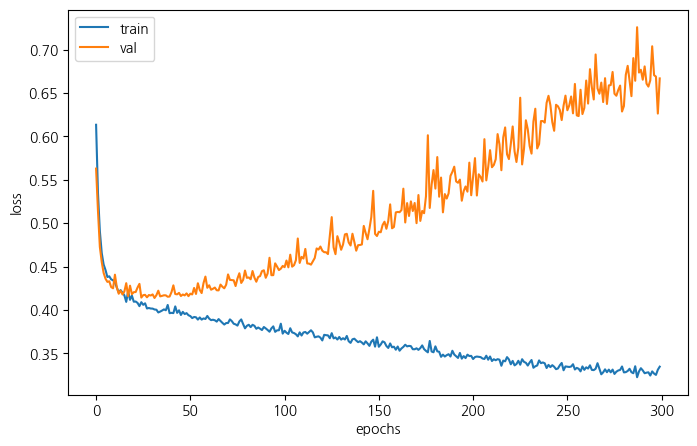

In [24]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

* val loss가 가장 낮은 지점이 가장 좋은 모델
    * 약 20~40 epoch 사이

# 모델 예측값 출력

In [25]:
pred = model.predict(X_test_ppd)
pred

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


array([[1.77183226e-01],
       [9.27170143e-02],
       [1.23245306e-01],
       [1.15938835e-01],
       [8.28439221e-02],
       [5.06266892e-01],
       [9.35551897e-02],
       [1.00000000e+00],
       [1.26005188e-01],
       [9.99925971e-01],
       [7.18979955e-01],
       [9.99796510e-01],
       [2.82432050e-01],
       [1.73473775e-01],
       [9.99884486e-01],
       [5.88762760e-01],
       [1.23245306e-01],
       [3.71335208e-01],
       [9.56642330e-01],
       [2.79006511e-01],
       [1.91967450e-02],
       [4.19737585e-02],
       [4.45704818e-01],
       [1.15938835e-01],
       [7.48001277e-01],
       [8.94291326e-02],
       [9.99858022e-01],
       [1.60148442e-01],
       [5.27749723e-03],
       [1.13326930e-01],
       [8.66576433e-01],
       [8.27523887e-01],
       [1.23245306e-01],
       [5.56948066e-01],
       [9.99004304e-01],
       [5.18517852e-01],
       [1.23245306e-01],
       [3.47568952e-02],
       [1.23245306e-01],
       [2.69065529e-01],


In [26]:
result = pd.DataFrame(dict(y_test=y_test, pred=pred[:,0]))
result['pred'] =  result['pred'].apply(lambda x: 1 if x >= 0.5 else 0)
result

,y_test,pred
625,0,0
566,0,0
459,0,0
804,1,0
338,1,0
...,...,...
184,1,1
607,1,0
624,0,0
103,0,0


# Functional API를 이용한 함수형 모델
* Sequential API는 단순히 층을 여러 개 쌓는 형태라 복잡한 모델 생성에 한계가 있음.
* Functional API는 입력층과 출력층을 사용자가 직접 정의 가능
* 다중입력(Multi-input), 다중출력(Multi-output)등 복잡한 모델을 정의 할 수 있음.
* Input(shape=(독립변수 수))로 입력층 정의
* 이전 층을 다음 층의 입력으로 사용
* model()에 입력과 출력을 정의

In [27]:
from keras.layers import Input, Dense
from keras.models import Model

In [28]:
# # 신경망 모델 정의 kearas 3.0, tensorflow 2.19 기준
# model = Sequential()
# model.add(Input(shape=(X_train_ppd.shape[1],))) # 입력층
# model.add(Dense(64, activation='relu')) # 은닉층
# model.add(Dense(32, activation='relu')) # 은닉층
# model.add(Dense(16, activation='relu')) # 은닉층
# model.add(Dense(1, activation='sigmoid')) # 출력층, 이진분류이므로 sigmoid

In [29]:
# 입력층
inputs = Input(shape=(X_test_ppd.shape[1],))

# 은닉층
x = Dense(64, activation='relu')(inputs)
x = Dense(32, activation='relu')(x)
x = Dense(16, activation='relu')(x)

# 출력층
outputs = Dense(1, activation='sigmoid')(x)

# 모델 정의
model = Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
from sklearn.metrics import classification_report

Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.6244 - loss: 0.6153 - val_accuracy: 0.7015 - val_loss: 0.5649
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7576 - loss: 0.5382 - val_accuracy: 0.8172 - val_loss: 0.5192
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8042 - loss: 0.5009 - val_accuracy: 0.8134 - val_loss: 0.4831
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8074 - loss: 0.4709 - val_accuracy: 0.8172 - val_loss: 0.4588
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8122 - loss: 0.4571 - val_accuracy: 0.8134 - val_loss: 0.4409
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8218 - loss: 0.4406 - val_accuracy: 0.8172 - val_loss: 0.4496
Epoch 7/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8026 - loss: 0.4462 - val_accuracy: 0.8097 - val_loss: 0.4282
Epoch 8/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8138 - loss: 0.4346 - val_accuracy: 0.8097 - 

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8347 - loss: 0.3906 - val_accuracy: 0.8097 - val_loss: 0.4173
Epoch 52/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8395 - loss: 0.3873 - val_accuracy: 0.7985 - val_loss: 0.4358
Epoch 53/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8363 - loss: 0.3879 - val_accuracy: 0.8022 - val_loss: 0.4240
Epoch 54/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8363 - loss: 0.3865 - val_accuracy: 0.8097 - val_loss: 0.4208
Epoch 55/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8427 - loss: 0.3837 - val_accuracy: 0.7836 - val_loss: 0.4249
Epoch 56/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8331 - loss: 0.3882 - val_accuracy: 0.8246 - val_loss: 0.4199
Epoch 57/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8395 - loss: 0.3854 - val_accuracy: 0.7948 - val_loss: 0.4218
Epoch 58/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8395 - loss: 0.3834 - val_accuracy: 0.8209 - val_lo

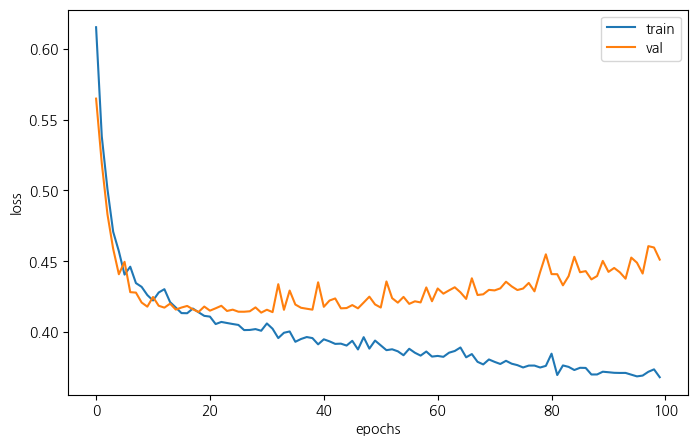

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       165
           1       0.77      0.67      0.72       103

    accuracy                           0.79       268
   macro avg       0.79      0.77      0.78       268
weighted avg       0.79      0.79      0.79       268



In [31]:
# 모델의 파라미터 세팅
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(X_train_ppd, y_train, epochs=100, batch_size=16,
                   validation_data=(X_test_ppd, y_test))
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()
pred = model.predict(X_test_ppd)
pred
result = pd.DataFrame(dict(y_test=y_test, pred=pred[:,0]))
result['pred'] =  result['pred'].apply(lambda x: 1 if x >= 0.5 else 0)
print(classification_report(result['y_test'], result['pred']))

# class형으로 만들기 (Model Subclass API)
* class 형태의 모델 정의 방법
* keras의 Model을 상속받아 작성

In [32]:
# # 입력층
# inputs = Input(shape=(X_test_ppd.shape[1],))

# # 은닉층
# x = Dense(64, activation='relu')(inputs)
# x = Dense(32, activation='relu')(x)
# x = Dense(16, activation='relu')(x)

# # 출력층
# outputs = Dense(1, activation='sigmoid')(x)

# # 모델 정의
# model = Model(inputs=inputs, outputs=outputs)
# model.summary()

In [33]:
class Titanic(Model):
    def __init__(self): # 레이어 생성
        super().__init__() # 입력층
        self.dense1 = Dense(128, activation='relu') # 은닉층
        self.dense2 = Dense(64, activation='relu')  # 은닉층
        self.dense3 = Dense(32, activation='relu')  # 은닉층
        self.dense4 = Dense(16, activation='relu')  # 은닉층
        self.outputs = Dense(1, activation='sigmoid') # 출력층
        
    def call(self, inputs): # 실제 모델
        x = self.dense1(inputs)
        x = self.dense2(x)
        x = self.dense3(x)
        x = self.dense4(x)
        return self.outputs(x)

In [34]:
model = Titanic()
print(model.summary())

Model: "titanic"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.6260 - loss: 0.6270 - val_accuracy: 0.7239 - val_loss: 0.5684
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7817 - loss: 0.5230 - val_accuracy: 0.8060 - val_loss: 0.4985
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7961 - loss: 0.4759 - val_accuracy: 0.7724 - val_loss: 0.4693
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8090 - loss: 0.4490 - val_accuracy: 0.7836 - val_loss: 0.4524
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7978 - loss: 0.4538 - val_accuracy: 0.8172 - val_loss: 0.4416
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8090 - loss: 0.4406 - val_accuracy: 0.8172 - val_loss: 0.4457
Epoch 7/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8154 - loss: 0.4349 - val_accuracy: 0.8060 - val_loss: 0.4292
Epoch 8/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8138 - loss: 0.4282 - val_accuracy: 0.7985 - 

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8395 - loss: 0.3828 - val_accuracy: 0.8209 - val_loss: 0.4212
Epoch 52/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8411 - loss: 0.3865 - val_accuracy: 0.7873 - val_loss: 0.4514
Epoch 53/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8283 - loss: 0.3865 - val_accuracy: 0.8097 - val_loss: 0.4200
Epoch 54/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8331 - loss: 0.3852 - val_accuracy: 0.7910 - val_loss: 0.4239
Epoch 55/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8443 - loss: 0.3816 - val_accuracy: 0.8097 - val_loss: 0.4233
Epoch 56/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8427 - loss: 0.3814 - val_accuracy: 0.8172 - val_loss: 0.4190
Epoch 57/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8395 - loss: 0.3842 - val_accuracy: 0.8022 - val_loss: 0.4322
Epoch 58/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8459 - loss: 0.3817 - val_accuracy: 0.8172 - val_lo

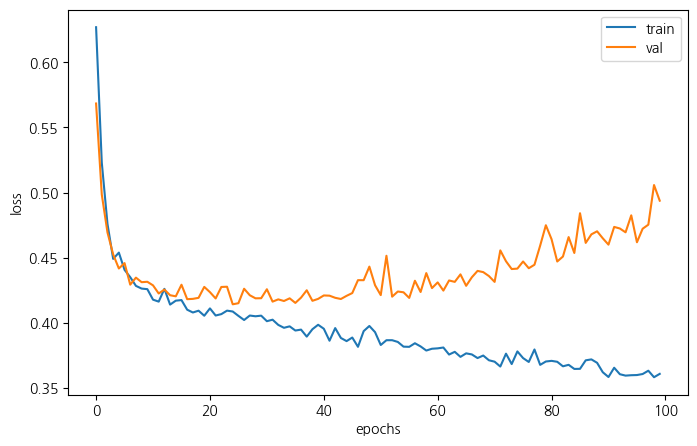

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
              precision    recall  f1-score   support

           0       0.79      0.89      0.84       165
           1       0.78      0.62      0.69       103

    accuracy                           0.79       268
   macro avg       0.79      0.76      0.76       268
weighted avg       0.79      0.79      0.78       268



In [35]:
# 모델의 파라미터 세팅
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(X_train_ppd, y_train, epochs=100, batch_size=16,
                   validation_data=(X_test_ppd, y_test))
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

pred = model.predict(X_test_ppd)
pred
result = pd.DataFrame(dict(y_test=y_test, pred=pred[:,0]))
result['pred'] =  result['pred'].apply(lambda x: 1 if x >= 0.5 else 0)
print(classification_report(result['y_test'], result['pred']))